In [36]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL
from nrem_analysis.utils import load_tsg, plot_intervals

from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap

input_dir = RAW_DIR / "dual"

shank_sc = [3, 3, 3, 3, 3, 3, 5, 3]
for i, mouse_id in enumerate(MOUSE_IDS_DUAL):
    turn_uid = loadmat(input_dir / mouse_id / "turn_uid.mat")["turn_uid"].squeeze() - 1 # convert to 0-indexed
    turn_index = loadmat(input_dir / mouse_id / "turn_index.mat")["turn_index"].squeeze()
        
    # Load SC shanks
    clu = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.clu.{shank_sc[i]}.npy").squeeze()
    res = np.load(input_dir / mouse_id / f"YutaTest{mouse_id}.res.{shank_sc[i]}.npy").squeeze()

    clu = clu[1:] # remove the number of clusters entry
    units = np.unique(clu).astype(int)
    units = units[(units != 0) & (units != 1)] # exclude noise and multiunit clusters
    tsg = load_tsg(values=res/20_000, ids=clu, select_ids=units)
    break

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
nrem            = sleep[sleep['state'] == 'nrem']
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

In [40]:
STATE_NAMES = ["continuous", "fragmented", "stationary"]
data_dir = INTERIM_DIR / "movement_var20" / mouse_id

virtual_hds = []
states      = []
for i, ep in enumerate(nrem.intersect(session[session['state'] == 'homecage'])):
    decoded = nap.load_file(data_dir / f"{mouse_id}_{i}.npz")
    vh = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
    virtual_hds.append(vh)
    states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
    states.append(states_i)

virtual_hds = np.concatenate(virtual_hds)
states = np.concatenate(states)
continuous_eps = states['continuous'].threshold(0.5).time_support

In [46]:
tsg

Index    rate
-------  --------
11       11.28855
12       4.3682
15       10.08097
16       53.97106
18       38.97421
19       8.31618
21       7.68395
...      ...
133      3.53994
145      1.16777
148      11.62656
149      10.31878
152      2.80649
153      0.25501
156      8.13287

In [ ]:
#sta = nap.compute_event_triggered_average(np.unwrap(head_direction, period=360), tsg, binsize=50, window=(-2000, 2000), time_unit='ms')


def circular_sta(features, events, **kwargs):
    # features: Circular data in radians
    features = np.column_stack([np.sin(features), np.cos(features)])
    sta = nap.compute_event_triggered_average(features, events, **kwargs)
    return nap.TsdFrame(t=sta.t, d=np.rad2deg(np.arctan2(sta[:, :, 0].d, sta[:, :, 1].d)))

num_bins        = 100
wake_binsize    = 10
nrem_binsize    = 1

sta_awake = circular_sta(np.deg2rad(head_direction), tsg, binsize=wake_binsize, window=(- wake_binsize * num_bins // 2, wake_binsize * num_bins // 2), time_unit='ms')

In [57]:
sta_nrem  = circular_sta(np.deg2rad(virtual_hds), tsg, binsize=nrem_binsize, window=(- nrem_binsize * num_bins // 2, nrem_binsize * num_bins // 2), time_unit='ms')

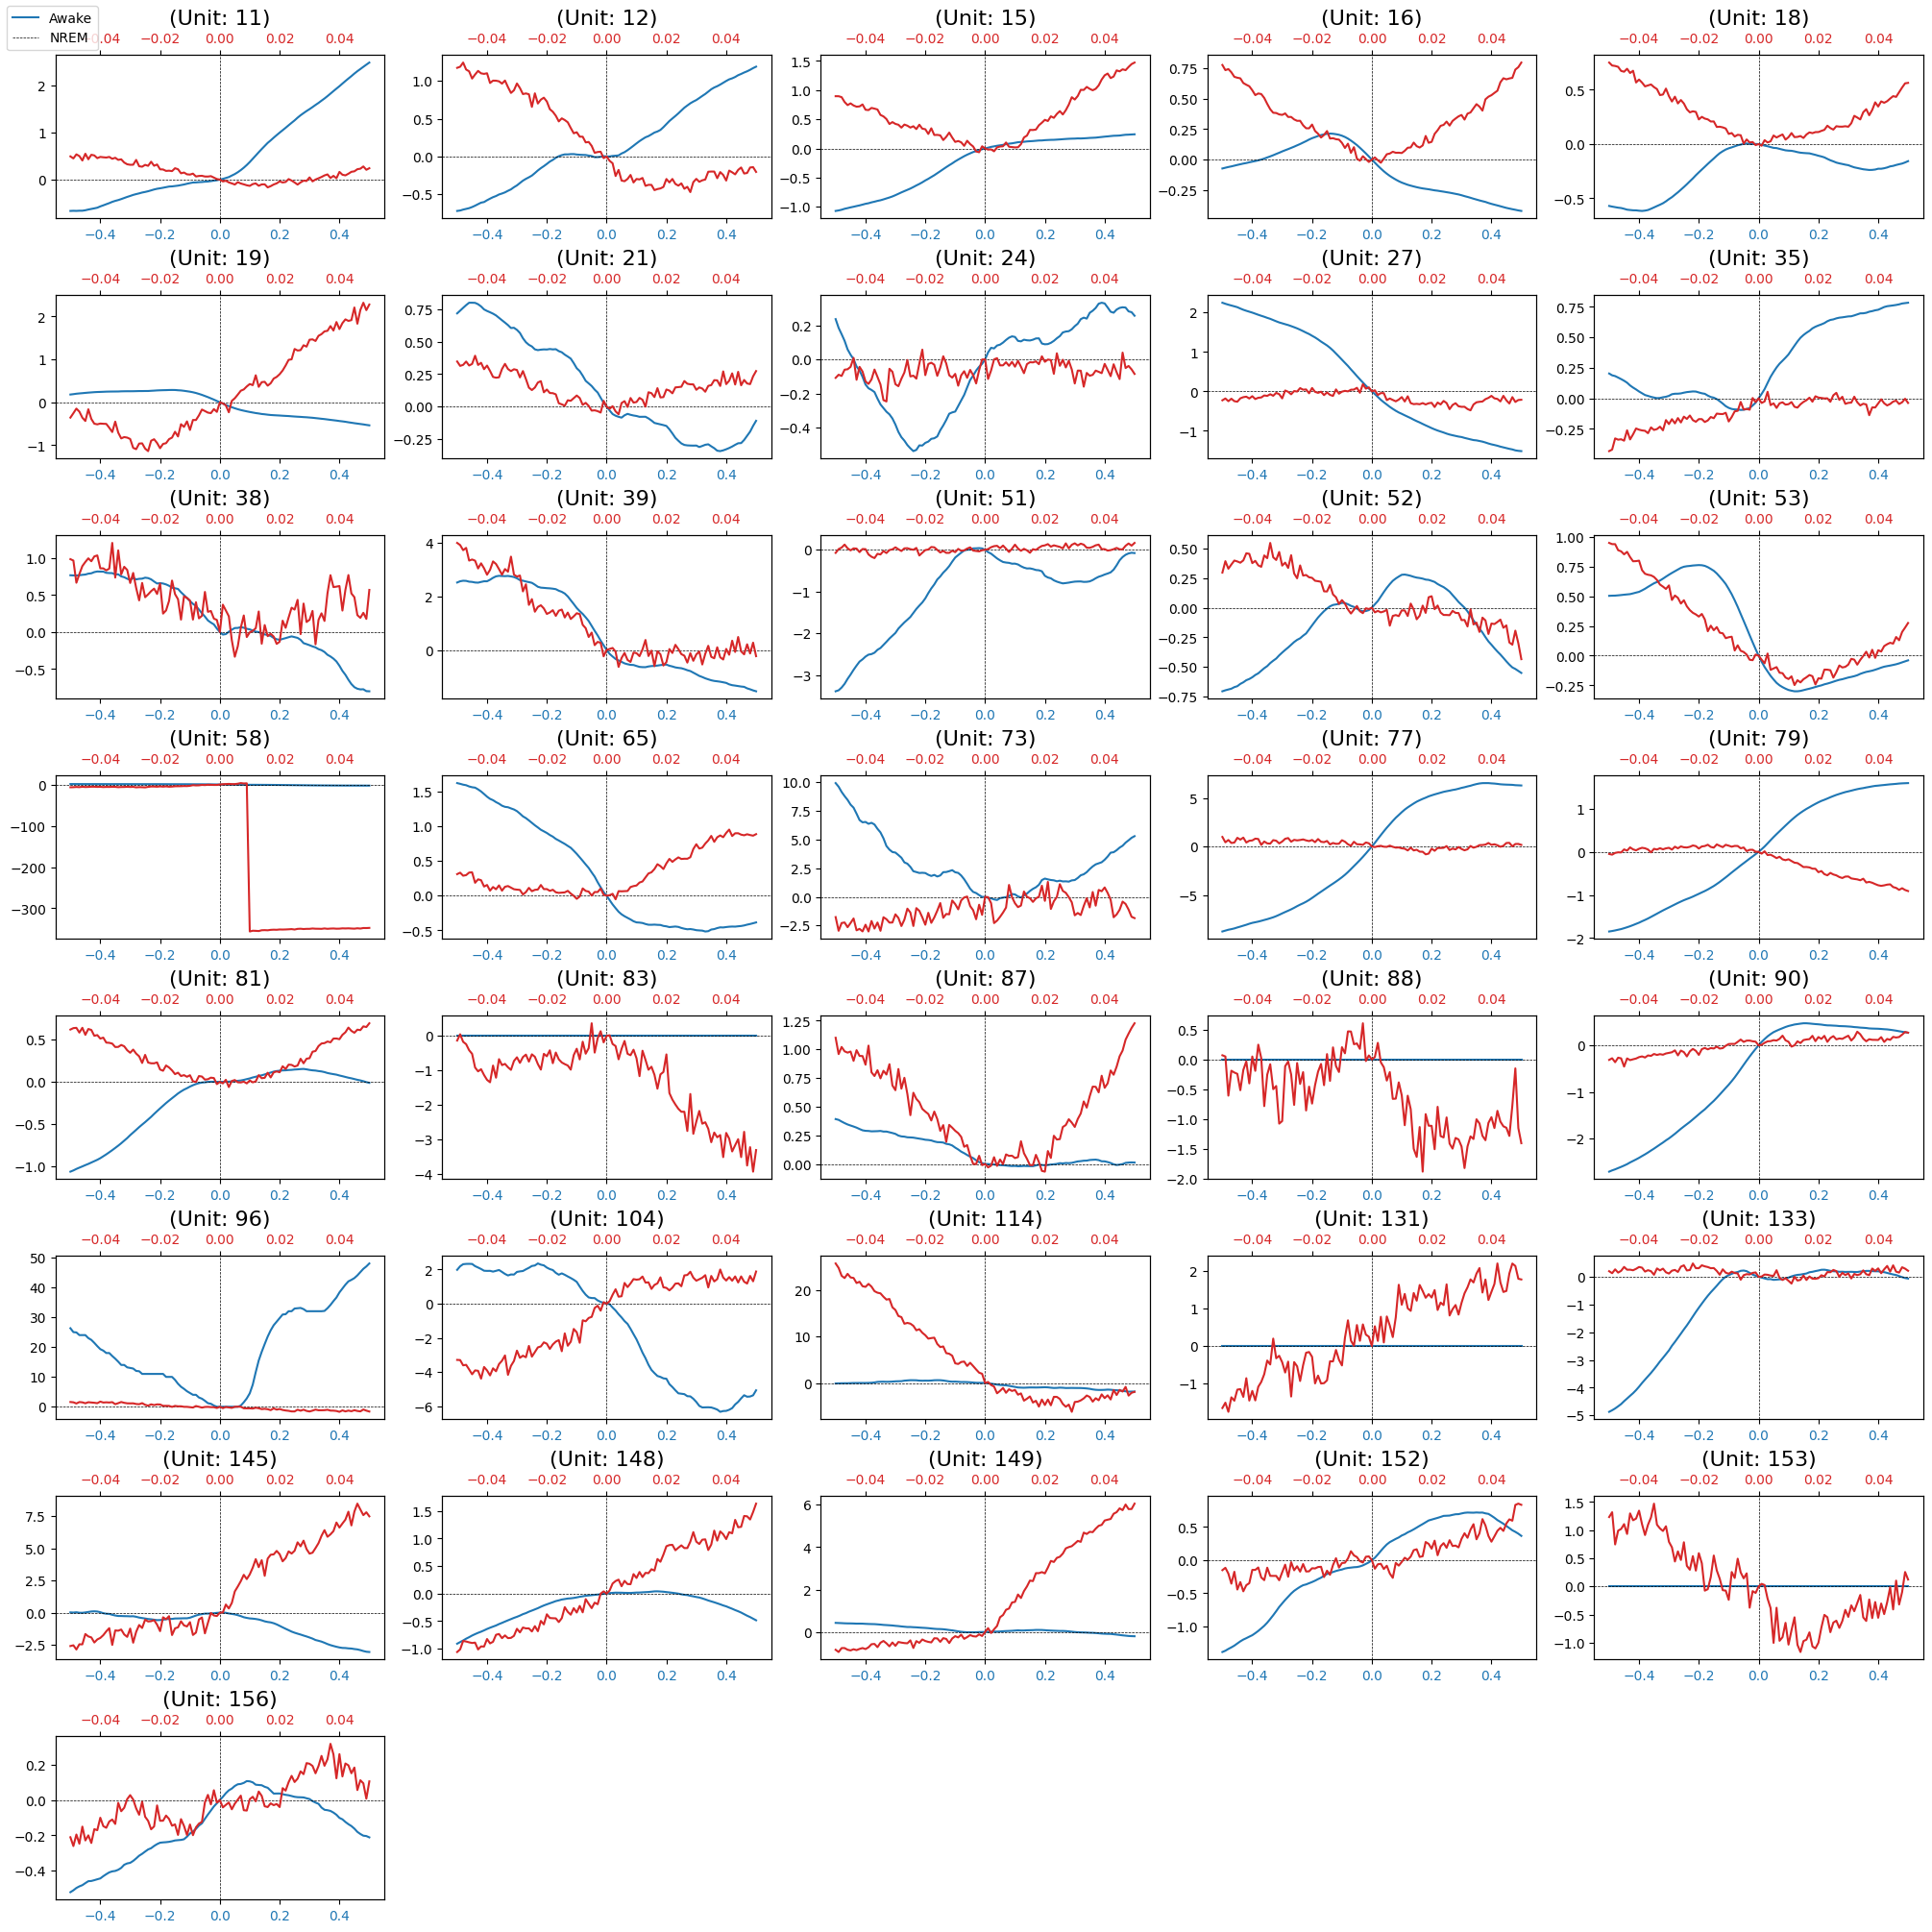

In [ ]:
assert sta_awake.shape[1] == sta_nrem.shape[1]

ncols = 5
nrows = int(np.ceil(sta_awake.shape[1] / ncols))

f, axs = plt.subplots(nrows, ncols, figsize=(20, 20), constrained_layout=True,)
axs = axs.flatten()

zero_idx = np.where(sta_awake.index == 0)[0].item()
sta_awake_norm = sta_awake - sta_awake[zero_idx, :]

zero_idx = np.where(sta_nrem.index == 0)[0].item()
sta_nrem_norm = sta_nrem - sta_nrem[zero_idx, :]

for i, uid in enumerate(tsg):
    ax1 = axs[i]

    color = 'tab:blue'
    ax1.plot(sta_awake_norm[:, i], color=color)
    ax1.tick_params(axis='x', labelcolor=color)

    ax2 = ax1.twiny()
    color = 'tab:red'
    ax2.plot(sta_nrem_norm[:, i], color=color)
    ax2.tick_params(axis='x', labelcolor=color)


    ax1.set_title(f"(Unit: {uid})", fontsize=16)
    ax1.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax1.axhline(0, color='k', linestyle='--', linewidth=0.5)

for i in range(ncols * nrows, sta_awake.shape[1], -1):
    axs[i-1].set_visible(False)

f.legend(["Awake", "NREM"], loc='upper left')
plt.show(f)

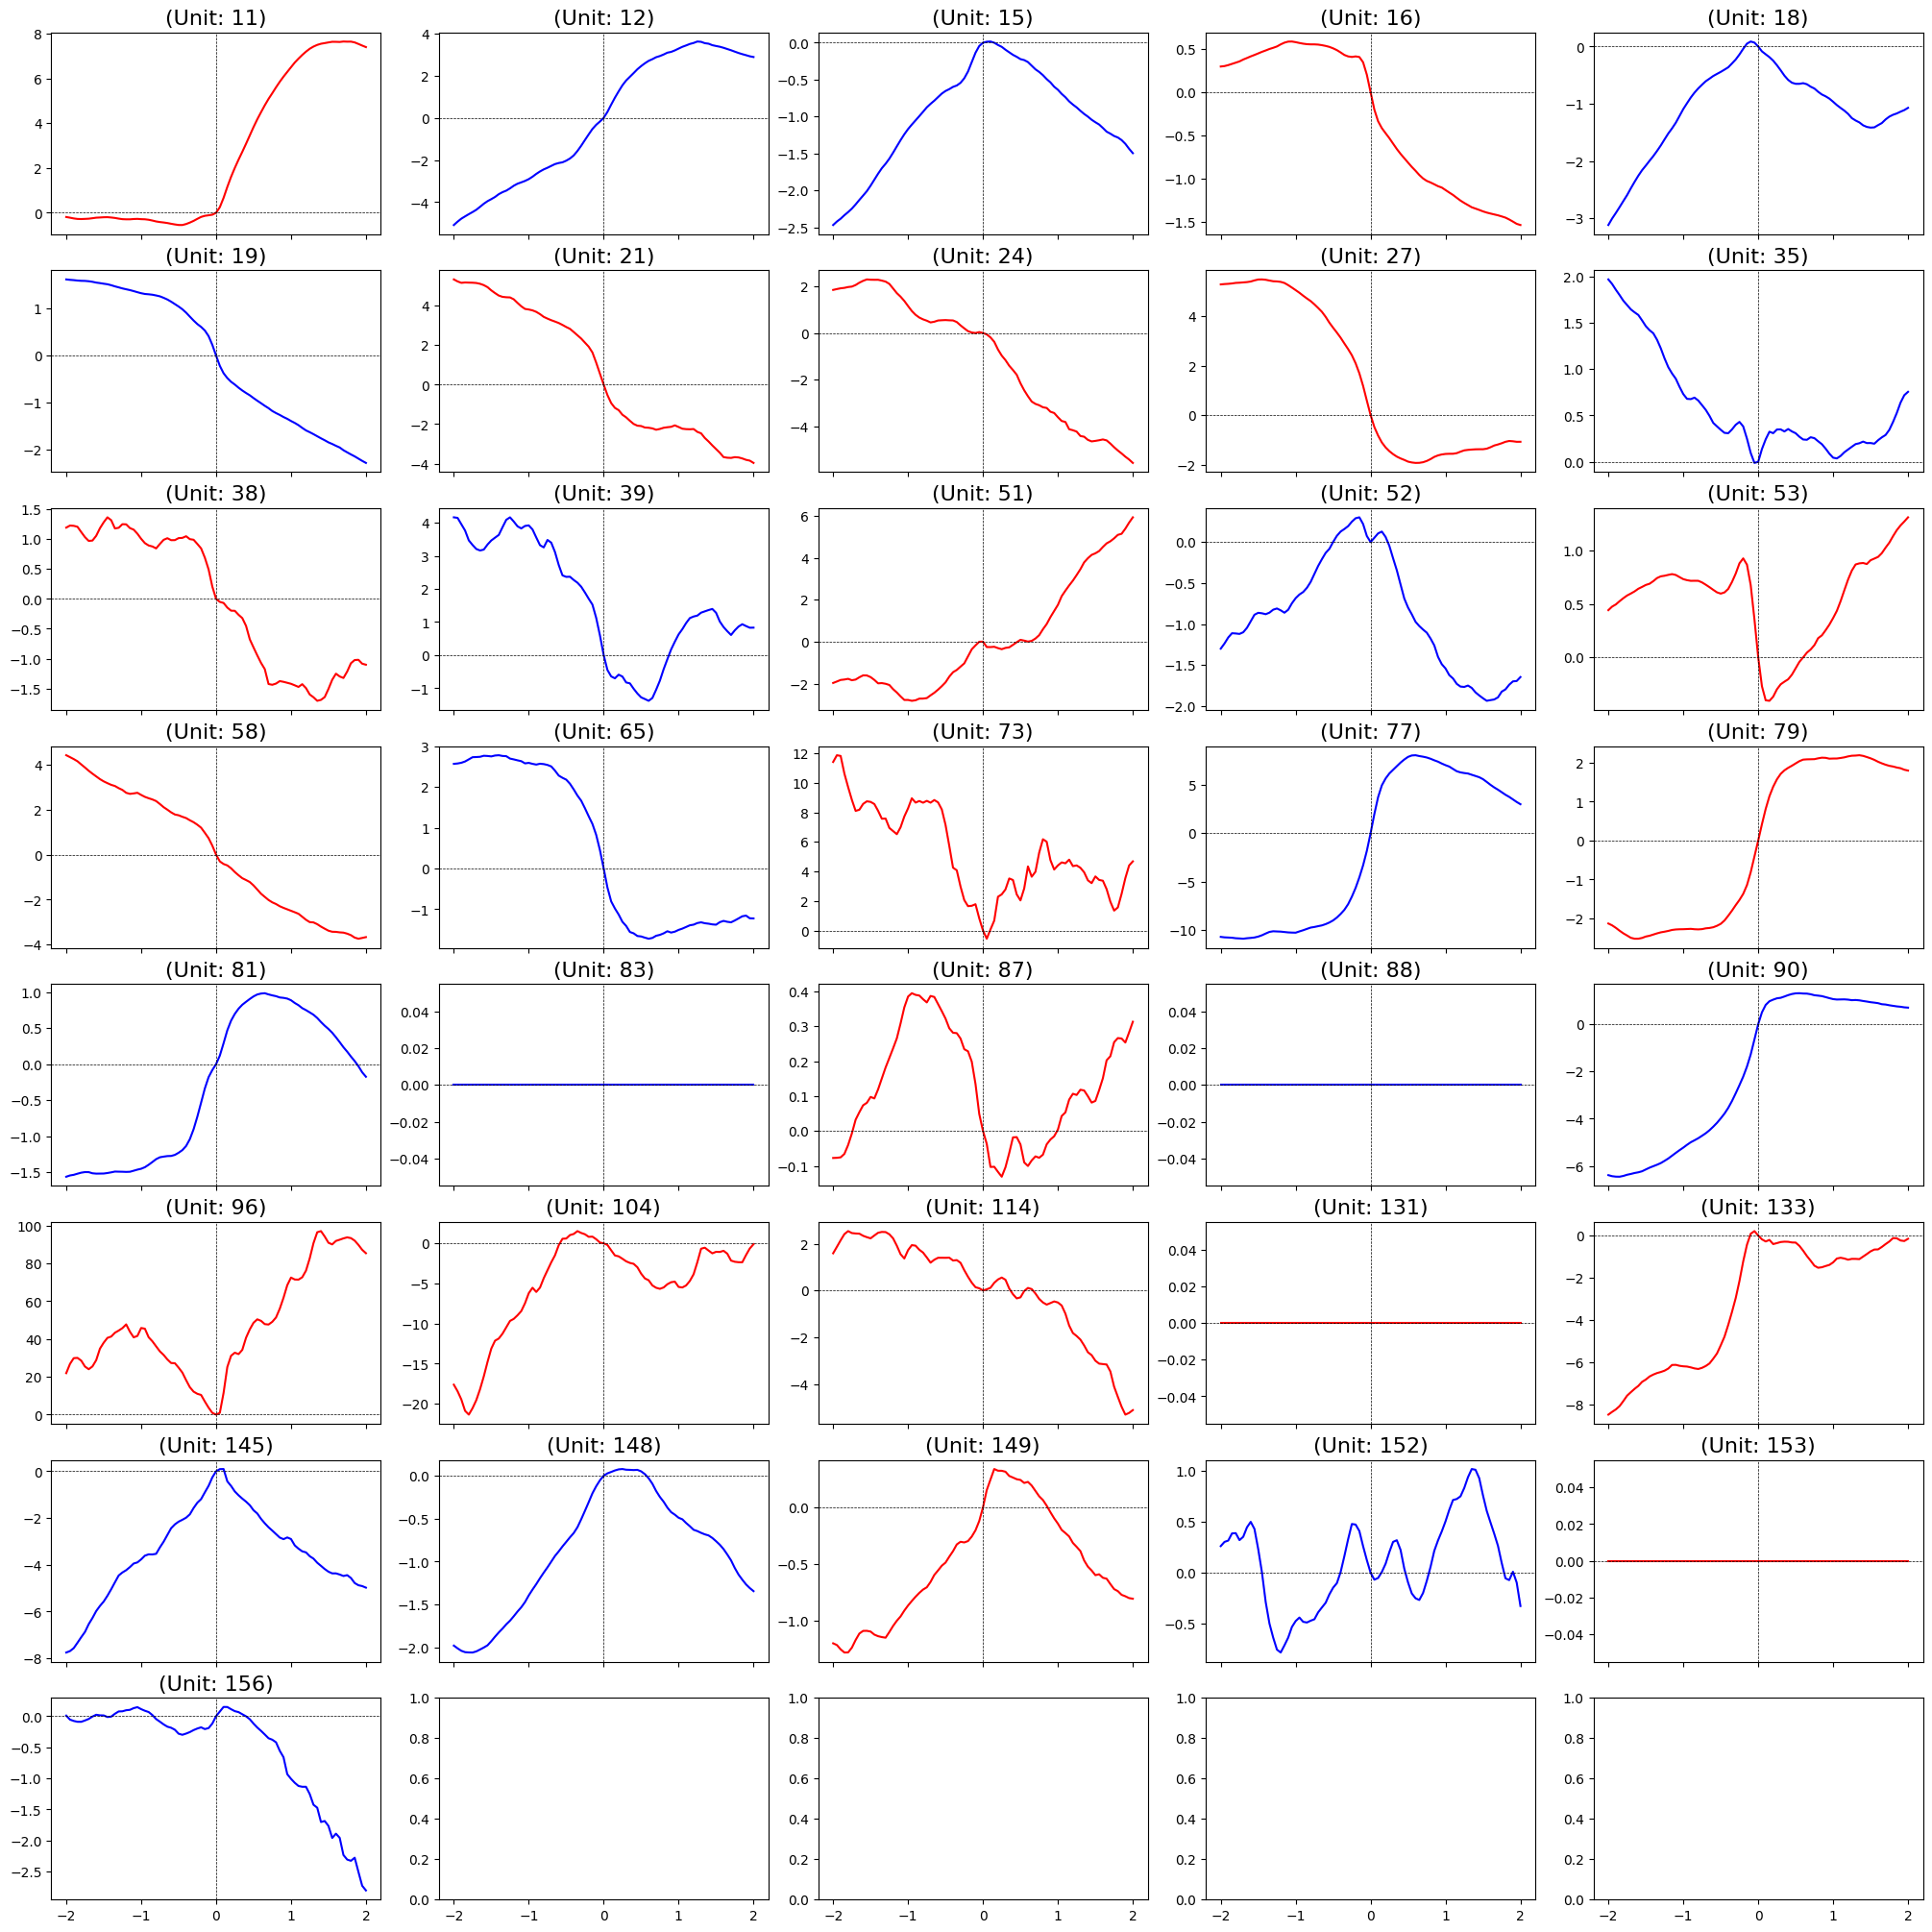

In [29]:
zero_idx = np.where(sta.index == 0)[0].item()
baseline = sta[zero_idx, :]
sta_norm = sta - baseline

ncols = 5
nrows = int(np.ceil(sta.shape[1] / ncols))

f, axs = plt.subplots(nrows, ncols, figsize=(20, 20), sharex=True, constrained_layout=True,)
axs = axs.flatten()

for i, uid in enumerate(tsg):
    ax = axs[i]

    if uid in turn_units.index:
        ax.plot(sta_norm[:, i], color='b')
        ax.set_title(f"(Unit: {uid})", fontsize=16)
    else:
        ax.plot(sta_norm[:, i], color='r')
        ax.set_title(f"(Unit: {uid})", fontsize=16)
    
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
